<a href="https://colab.research.google.com/github/Suleymanov23/Afisha-marketing-analysis/blob/main/afisha_marketing_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Marketing Analysis for Yandex.Afisha
### DAU/WAU/MAU, session behavior, retention, LTV, CAC and ROI

This notebook is my project at Yandex.Afisha. The company wants to know how people use the product, when they start buying, how much money each customer brings, and where the marketing budget pays off.

I followed the three steps (prepare the data, build the reports, write a conclusion)

## Step 1. Load the data and get it ready for analysis

I have three tables:
- **visits** - server logs of every session on the website
- **orders** - every purchase made
- **costs** - daily marketing spend per ad source

First I load them, look at their structure, fix column names and data types, and check for the usual problems (missing values, duplicates, incorrect types). I will also check if the `source_id` values match between the visits table and the costs table, because if a source appears in visits but never in costs, my cost-per-source math will break later.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


I load the three CSV files and look at the first rows and the column info, so I know what I am working with before changing anything.

In [ ]:
visits = pd.read_csv('/content/drive/MyDrive/ Business Analytics 3/visits_log_us.csv')
orders = pd.read_csv('/content/drive/MyDrive/ Business Analytics 3/orders_log_us.csv')
costs = pd.read_csv('/content/drive/MyDrive/ Business Analytics 3/costs_us.csv')

print(visits.head())
print(orders.head())
print(costs.head())

    Device               End Ts  Source Id             Start Ts  \
0    touch  2017-12-20 17:38:00          4  2017-12-20 17:20:00   
1  desktop  2018-02-19 17:21:00          2  2018-02-19 16:53:00   
2    touch  2017-07-01 01:54:00          5  2017-07-01 01:54:00   
3  desktop  2018-05-20 11:23:00          9  2018-05-20 10:59:00   
4  desktop  2017-12-27 14:06:00          3  2017-12-27 14:06:00   

                    Uid  
0  16879256277535980062  
1    104060357244891740  
2   7459035603376831527  
3  16174680259334210214  
4   9969694820036681168  
                Buy Ts  Revenue                   Uid
0  2017-06-01 00:10:00    17.00  10329302124590727494
1  2017-06-01 00:25:00     0.55  11627257723692907447
2  2017-06-01 00:27:00     0.37  17903680561304213844
3  2017-06-01 00:29:00     0.55  16109239769442553005
4  2017-06-01 07:58:00     0.37  14200605875248379450
   source_id          dt  costs
0          1  2017-06-01  75.20
1          1  2017-06-02  62.25
2          1  2017-06

In [ ]:
visits.info()
orders.info()
costs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 

Column names are a mix of capital letters and spaces (`Start Ts`, `Source Id`), which is not convenient to work with. Also, all date/time columns are stored as 'object', not as dates. I need to fix both things before I can group by day, week, or month.

In [ ]:
visits.columns = ['device', 'end_ts', 'source_id', 'start_ts', 'uid']
orders.columns = ['buy_ts', 'revenue', 'uid']
costs.columns  = ['source_id', 'dt', 'costs']

visits['start_ts'] = pd.to_datetime(visits['start_ts'])
visits['end_ts'] = pd.to_datetime(visits['end_ts'])
visits['device'] = visits['device'].astype('category')
orders['buy_ts'] = pd.to_datetime(orders['buy_ts'])
costs['dt'] = pd.to_datetime(costs['dt'])

visits.dtypes

,0
device,category
end_ts,datetime64[ns]
source_id,int64
start_ts,datetime64[ns]
uid,uint64


Now I check for missing values and duplicate rows in all three tables. This is a standard check, but I still have to do it before trusting any number that comes later.

In [ ]:
print(f"visits: missing values = {visits.isna().sum().sum()}, duplicate rows = {visits.duplicated().sum()}")
print(f"orders: missing values = {orders.isna().sum().sum()}, duplicate rows = {orders.duplicated().sum()}")
print(f"costs: missing values = {costs.isna().sum().sum()}, duplicate rows = {costs.duplicated().sum()}")

visits: missing values = 0, duplicate rows = 0
orders: missing values = 0, duplicate rows = 0
costs: missing values = 0, duplicate rows = 0


No missing values and no duplicate rows in any of the three tables.

I also want to know if every `source_id` that shows up in `visits` also has a row in `costs`. If a source has traffic but no recorded cost, I cannot calculate a real CAC or ROI for it later, and I need to know that in advance instead of getting a strange `NaN` in the middle of a chart.

In [ ]:
visit_sources = set(visits['source_id'].unique())
cost_sources  = set(costs['source_id'].unique())
missing_cost_sources = visit_sources - cost_sources
print("Sources with visits but no cost record:", missing_cost_sources)

# I count users by their FIRST-EVER visit source, because that's the same logic I use later for CAC/ROI
first_touch = visits.sort_values('start_ts').groupby('uid').first()['source_id']
for s in sorted(missing_cost_sources):
    users = (first_touch == s).sum()
    print(f"  source {s}: {users} users had their FIRST visit through this source")

Sources with visits but no cost record: {np.int64(6), np.int64(7)}
  source 6: 2 users had their FIRST visit through this source
  source 7: 32 users had their FIRST visit through this source


**Result:** sources `6` and `7` never appear in the costs table. At first this looked like it could be "free" organic traffic worth investigating. But when I check the volume, source 6 only has 2 unique users and source 7 has 32ç that's tiny compared to the other sources (tens of thousands of users each). So this is not a meaningful free channel, it's most likely test traffic or a very minor referral source. I'll keep these two sources in the product metrics (DAU, sessions, retention), but I will leave them out of the **CAC / ROI** calculations later, since there is no cost data to divide by and the volume is too small.

I check that the three tables actually cover the same period, because if `visits` and `orders` don't overlap properly, later cohort comparisons would be misleading.

In [ ]:
print("visits:", visits['start_ts'].min(), "-", visits['start_ts'].max())
print("orders:", orders['buy_ts'].min(), "-", orders['buy_ts'].max())
print("costs :", costs['dt'].min(), "-", costs['dt'].max())

visits: 2017-06-01 00:01:00 - 2018-05-31 23:59:00
orders: 2017-06-01 00:10:00 - 2018-06-01 00:02:00
costs : 2017-06-01 00:00:00 - 2018-05-31 00:00:00


All three tables cover roughly June 1, 2017 to the end of May 2018 (orders has a few purchases that spill into June 1, 2018, which is fine, those are just orders placed right at the boundary). The data is ready. Now I can move to the actual metrics.

## Step 2. Reports and metrics

### 2.1 Product- how many people use it, and how

I'll start with DAU, WAU and MAU (daily / weekly / monthly active users). On their own these three numbers don't say much, so I also calculate the sticky factor (DAU/WAU and DAU/MAU). This tells me what share of the weekly or monthly audience is active on an average single day, basically, how often a typical user comes back.

In [ ]:
visits['date']  = visits['start_ts'].dt.date
visits['week']  = visits['start_ts'].dt.to_period('W')
visits['month'] = visits['start_ts'].dt.to_period('M')

dau_by_day = visits.groupby('date')['uid'].nunique()
wau_by_week = visits.groupby('week')['uid'].nunique()
mau_by_month = visits.groupby('month')['uid'].nunique()

dau, wau, mau = dau_by_day.mean(), wau_by_week.mean(), mau_by_month.mean()
sticky_wau = dau / wau
sticky_mau = dau / mau

print(f"Average DAU: {dau:,.0f}")
print(f"Average WAU: {wau:,.0f}")
print(f"Average MAU: {mau:,.0f}")
print(f"Sticky factor (DAU/WAU): {sticky_wau:.1%}")
print(f"Sticky factor (DAU/MAU): {sticky_mau:.1%}")

Average DAU: 908
Average WAU: 5,716
Average MAU: 23,228
Sticky factor (DAU/WAU): 15.9%
Sticky factor (DAU/MAU): 3.9%


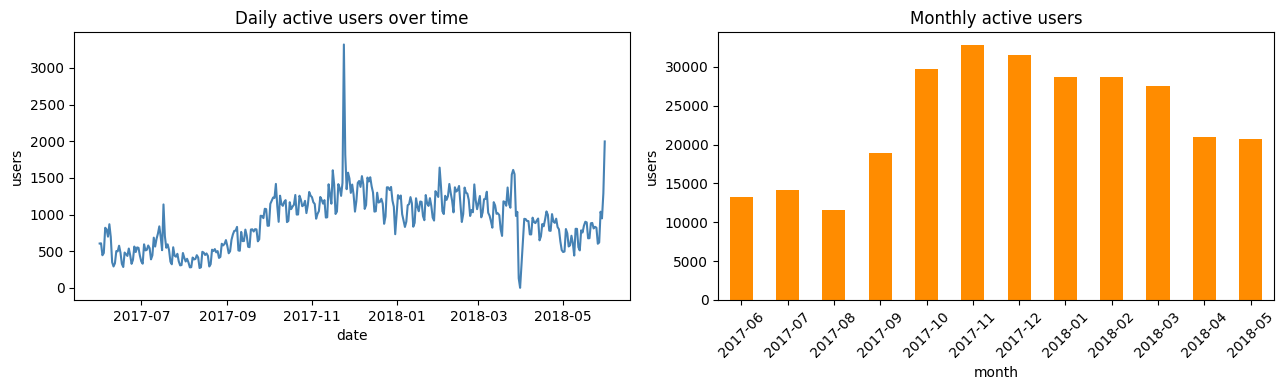

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
dau_by_day.plot(ax=axes[0], color='steelblue')
axes[0].set_title('Daily active users over time')
axes[0].set_ylabel('users')

mau_by_month.plot(ax=axes[1], kind='bar', color='darkorange')
axes[1].set_title('Monthly active users')
axes[1].set_ylabel('users')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

On an average day about 908 people visit the site, in an average week about 5,716, and in an average month about 23,228. The sticky factor is only 15.9% for the week and 3.9% for the month. In other words: out of everyone who visits in a month, less than 4 out of 100 show up on any single given day. There is also a clear seasonal beahivour, MAU rises through the winter and drops in the summer months, which fits an events/tickets platform (more indoor events and holidays in colder months). Low stickiness is not automatically bad here: Afisha is a service you check when you're planning to go somewhere, not something people open daily. Still, it tells marketing that ads should aim at retention, not at daily habit-building.

### 2.2 Sessions and session length

In [ ]:
sessions_per_day = visits.groupby('date')['uid'].count()
visits['duration_min'] = (visits['end_ts'] - visits['start_ts']).dt.total_seconds() / 60

print(f"Average sessions per day: {sessions_per_day.mean():,.0f}")
print(f"Mean session length: {visits['duration_min'].mean():.1f} minutes")
print(f"Median session length: {visits['duration_min'].median():.1f} minutes")

Average sessions per day: 987
Mean session length: 10.7 minutes
Median session length: 5.0 minutes


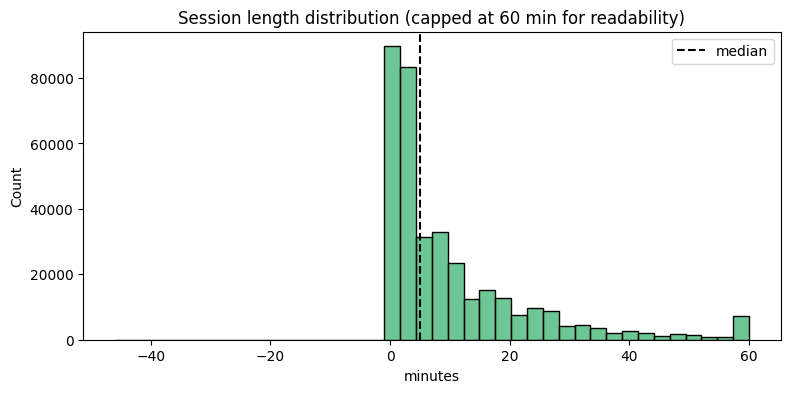

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(visits['duration_min'].clip(upper=60), bins=40, color='mediumseagreen')
plt.axvline(visits['duration_min'].median(), color='black', linestyle='--', label='median')
plt.title('Session length distribution (capped at 60 min for readability)')
plt.xlabel('minutes')
plt.legend()
plt.show()

There are about 987 sessions per day, a little bit more than the DAU (908), so most active users open just one session a day. Session length is heavily skewed. The mean is 10.7 minutes but the median is only 5 minutes. A small number of very long sessions (some over 20 hours) pull the average up. This is why I'll use the median, not the mean.

Desktop and mobile sessions look different in the data. Instead of just eyeballing the medians, I want to check if the difference is actually statistically meaningful or if it could just be random noise. Because session length is so skewed (as I showed), a normal t-test isn't for this, I'll use the Mann-Whitney U test, which compares distributions without assuming they are bell-shaped.

In [ ]:
desktop_dur = visits.loc[visits['device'] == 'desktop', 'duration_min']
mobile_dur = visits.loc[visits['device'] == 'touch', 'duration_min']

print("Median session length - desktop:", desktop_dur.median(), "min | touch:", mobile_dur.median(), "min")

u_stat, p_value = stats.mannwhitneyu(desktop_dur, mobile_dur, alternative='two-sided')
print(f"Mann-Whitney U test p-value: {p_value:.2e}")

Median session length - desktop: 6.0 min | touch: 3.0 min
Mann-Whitney U test p-value: 0.00e+00


Desktop sessions last a median of 6 minutes vs 3 minutes on mobile devices, and the p-value is far below 0.05. So this gap is real, people genuinely spend more time per session on desktop. Combined with the fact that desktop makes up 73% of all visits (I calculate this in the next section), desktop looks like the more "serious" browsing device for this product.

### 2.3 Retention rate

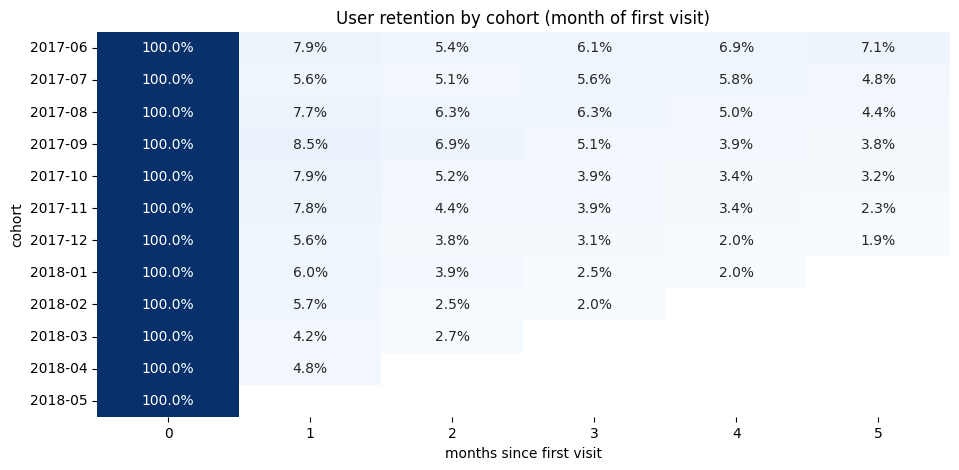

Average 1-month retention across all cohorts: 6.5%


In [ ]:
first_visit_month = visits.groupby('uid')['start_ts'].min().dt.to_period('M').rename('cohort')
v = visits.join(first_visit_month, on='uid')
v['cohort_age'] = (v['month'] - v['cohort']).apply(lambda x: x.n)

cohort_sizes = v[v['cohort_age'] == 0].groupby('cohort')['uid'].nunique()
active_by_age = v.groupby(['cohort', 'cohort_age'])['uid'].nunique().unstack()
retention = active_by_age.divide(cohort_sizes, axis=0)

plt.figure(figsize=(11, 5))
sns.heatmap(retention.iloc[:, :6], annot=True, fmt='.1%', cmap='Blues', cbar=False)
plt.title('User retention by cohort (month of first visit)')
plt.xlabel('months since first visit')
plt.ylabel('cohort')
plt.show()

print("Average 1-month retention across all cohorts:", f"{retention[1].mean():.1%}")

Month0 is always 100% normally (that's the whole cohort on their first month). By month1, retention drops to around 6.5% on average, and it stays roughly flat (5–8%) after that instead of dropping further. This matches the sticky-factor finding above: this is not a daily habit product, people come, maybe buy a ticket, and come back only when they need something new, a small stable core keeps returning every month.

### 2.4 Device split and weekly rhythm

Which device and which day should we target ads for?

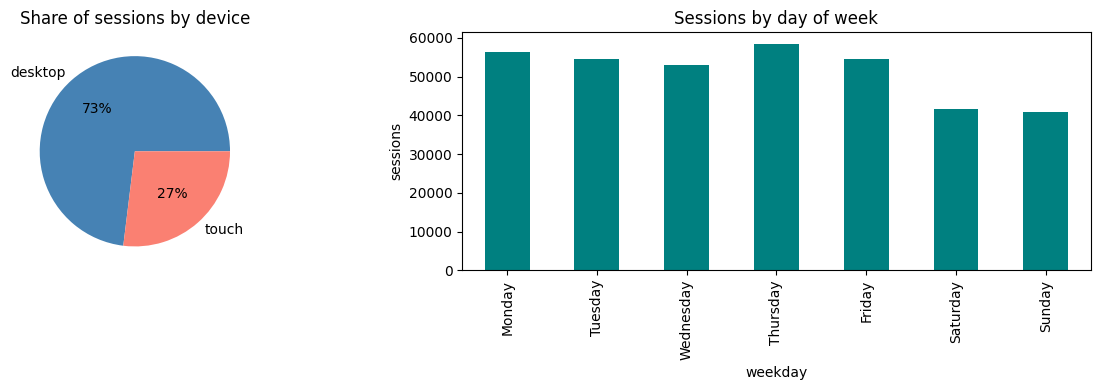

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

device_share = visits['device'].value_counts(normalize=True)
axes[0].pie(device_share, labels=device_share.index, autopct='%1.0f%%', colors=['steelblue', 'salmon'])
axes[0].set_title('Share of sessions by device')

visits['weekday'] = visits['start_ts'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
visits.groupby('weekday')['uid'].count().reindex(order).plot(kind='bar', ax=axes[1], color='teal')
axes[1].set_title('Sessions by day of week')
axes[1].set_ylabel('sessions')
plt.tight_layout()
plt.show()

Desktop makes up 73% of all sessions, touch only 27%. Traffic is also clearly lower in weekends than on weekdays, it looks like people plan their weekend earlier. This is useful for scheduling ad campaigns: front-loading spend early-to-mid week could reach people while they're actually deciding, instead of after they might have already planned something.

### 3.1 Sales - when do people start buying?

Here I look at the gap between a user's first visit and their first purchase. I bucket users by how many days it took them to convert, which lets me compare cohorts and sources by how fast they buy.

In [ ]:
first_visit = visits.groupby('uid')['start_ts'].min().reset_index(name='first_visit')
first_order = orders.groupby('uid')['buy_ts'].min().reset_index(name='first_order')

conv = first_visit.merge(first_order, on='uid', how='inner')
conv['conv_days'] = (conv['first_order'] - conv['first_visit']).dt.days

overall_conv_rate = len(first_order) / len(first_visit)
print(f"Overall visitor-to-buyer conversion rate: {overall_conv_rate:.1%}")
print(f"Share converting the same day:  {(conv['conv_days'] == 0).mean():.1%}")
print(f"Share converting within 7 days: {(conv['conv_days'] <= 7).mean():.1%}")

Overall visitor-to-buyer conversion rate: 16.0%
Share converting the same day:  72.2%
Share converting within 7 days: 80.6%


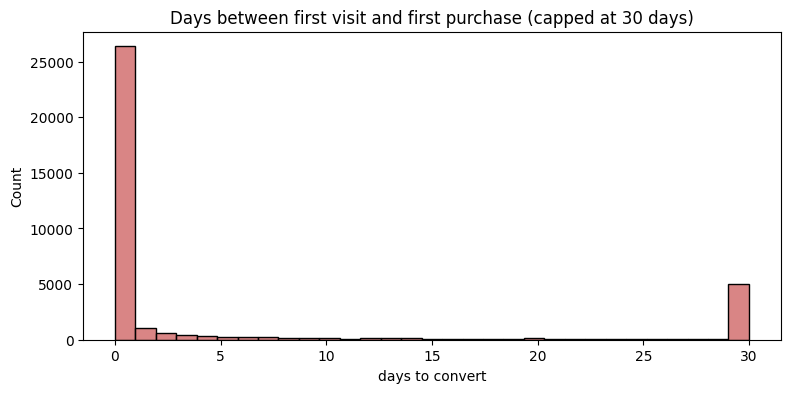

In [ ]:
plt.figure(figsize=(9, 4))
sns.histplot(conv['conv_days'].clip(upper=30), bins=31, color='indianred')
plt.title('Days between first visit and first purchase (capped at 30 days)')
plt.xlabel('days to convert')
plt.show()

16 % of all visitors eventually buy something - a solid conversion rate for this kind of product. Those who convert, 72% buy on the same day as their first visit, and 81% buy within a week. So this is a fast-decision product: if someone is going to buy, they usually decide almost immediately. That's important for marketing, a channel that brings visitors who take weeks to decide is probably a worse fit for this business than a channel that brings people ready to act now.

### 3.2 Orders and average purchase size

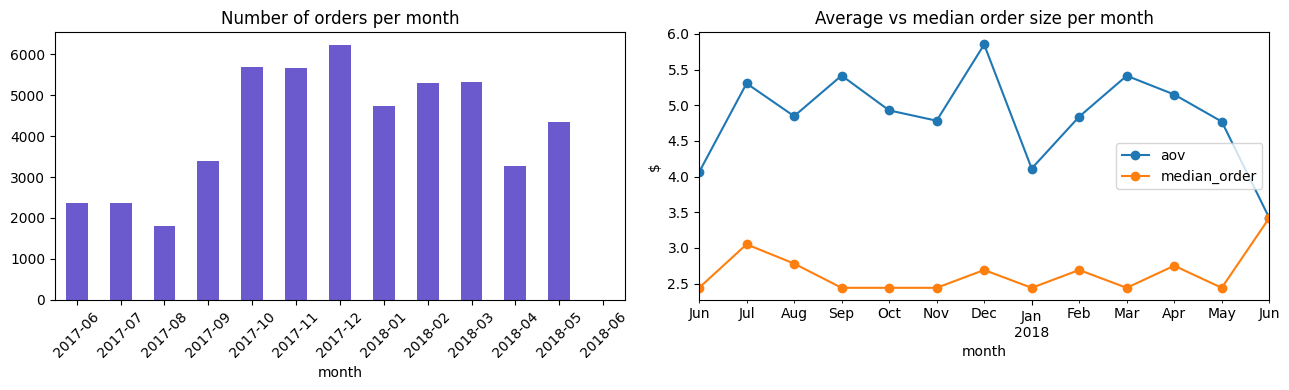

In [ ]:
orders['month'] = orders['buy_ts'].dt.to_period('M')
monthly_orders = orders.groupby('month').agg(order_count=('uid', 'count'), aov=('revenue', 'mean'), median_order=('revenue', 'median'))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
monthly_orders['order_count'].plot(kind='bar', ax=axes[0], color='slateblue')
axes[0].set_title('Number of orders per month')
axes[0].tick_params(axis='x', rotation=45)

monthly_orders[['aov', 'median_order']].plot(ax=axes[1], marker='o')
axes[1].set_title('Average vs median order size per month')
axes[1].set_ylabel('$')
plt.tight_layout()
plt.show()

The average order value line sits well above the median line in the chart above, every single month. That's the same skew pattern I saw with session length, so I want to measure exactly how much a few big orders are pulling the average up.

In [ ]:
top1 = orders.nlargest(int(len(orders) * 0.01), 'revenue')
share_of_revenue = top1['revenue'].sum() / orders['revenue'].sum()
print(f"The top 1% of orders (by size) account for {share_of_revenue:.1%} of all revenue.")
print(f"Overall average order value: ${orders['revenue'].mean():.2f} | median: ${orders['revenue'].median():.2f}")

The top 1% of orders (by size) account for 21.3% of all revenue.
Overall average order value: $5.00 | median: $2.50


Top 1% of orders bring 21.3% of all revenue. The overall average order is $5 but the median is only $2.5. So a handful of big spenders (or big group bookings) are doing a lot of work. When I calculate LTV per source below, I'll keep this in mind: a source that "wins" on LTV might just have gotten lucky with one or two big spenders

### 3.3 LTV - how much money does each customer bring?

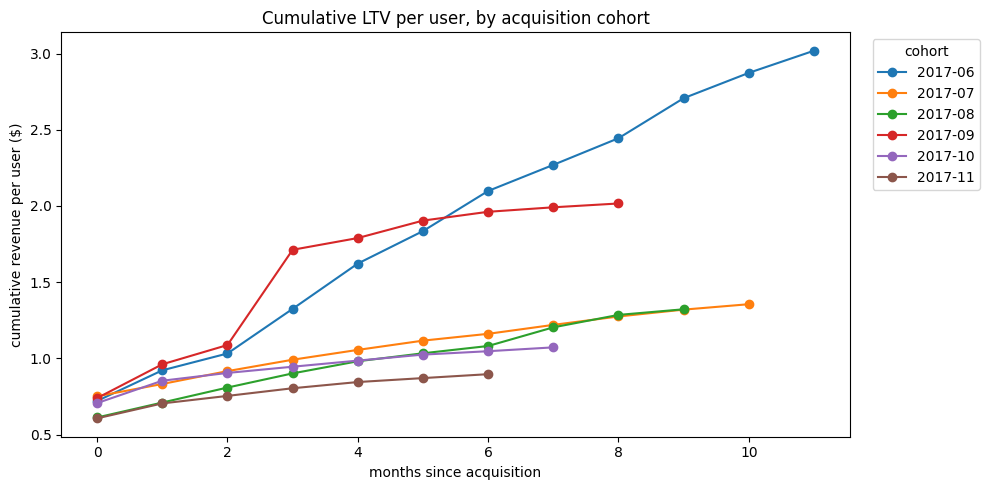

age,0,1,2,3,4,5
cohort,,,,,,
2017-06,0.72,0.92,1.03,1.33,1.62,1.84
2017-07,0.75,0.83,0.92,0.99,1.06,1.12
2017-08,0.61,0.71,0.81,0.90,0.98,1.03
2017-09,0.74,0.96,1.09,1.71,1.79,1.90
2017-10,0.71,0.85,0.90,0.95,0.99,1.02
2017-11,0.61,0.70,0.75,0.80,0.84,0.87


In [ ]:
fv_full = visits.sort_values('start_ts').groupby('uid').first()[['start_ts', 'source_id']].reset_index()
fv_full['cohort'] = fv_full['start_ts'].dt.to_period('M')

orders_c = orders.merge(fv_full[['uid', 'cohort']], on='uid')
orders_c['age'] = (orders_c['month'] - orders_c['cohort']).apply(lambda x: x.n)

cohort_n = fv_full.groupby('cohort')['uid'].nunique()
ltv_cum = orders_c.groupby(['cohort', 'age'])['revenue'].sum().groupby(level=0).cumsum().unstack()
ltv_per_user = ltv_cum.divide(cohort_n, axis=0)

plt.figure(figsize=(10, 5))
for cohort in ltv_per_user.index[:6]:
    plt.plot(ltv_per_user.columns, ltv_per_user.loc[cohort], marker='o', label=str(cohort))
plt.title('Cumulative LTV per user, by acquisition cohort')
plt.xlabel('months since acquisition')
plt.ylabel('cumulative revenue per user ($)')
plt.legend(title='cohort', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

ltv_per_user.round(2).iloc[:6, :6]

LTV per user grows steadily over time for every cohort, which makes sense, the longer you track a cohort, the more purchases it has a chance to make. The June 2017 cohort (the oldest, so it had the most time to gwor) reaches the highest cumulative LTV.

### 4.1 Marketing - how much money was spent?

Total marketing spend (Jun 2017 - May 2018): $329,131.62


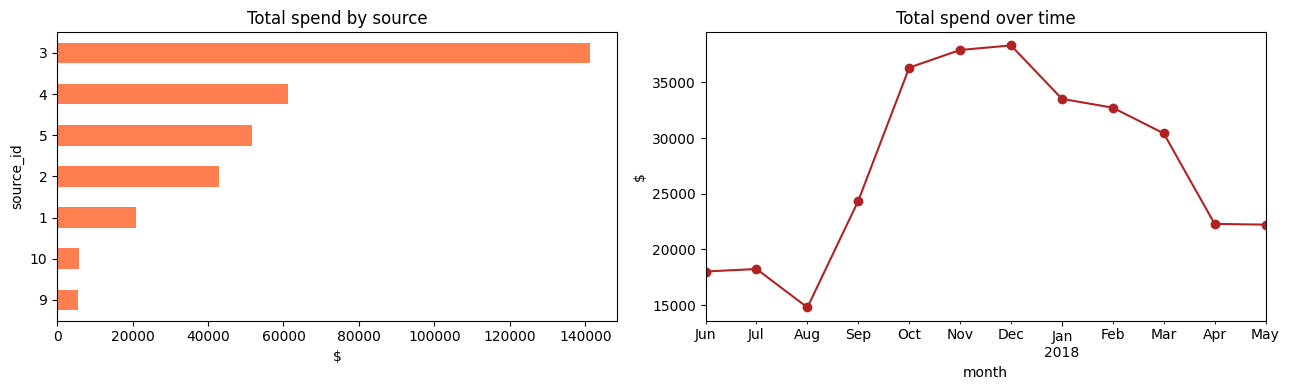

In [ ]:
total_cost = costs['costs'].sum()
print(f"Total marketing spend (Jun 2017 - May 2018): ${total_cost:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
costs.groupby('source_id')['costs'].sum().sort_values().plot(kind='barh', ax=axes[0], color='coral')
axes[0].set_title('Total spend by source')
axes[0].set_xlabel('$')

costs['month'] = costs['dt'].dt.to_period('M')
costs.groupby('month')['costs'].sum().plot(ax=axes[1], marker='o', color='firebrick')
axes[1].set_title('Total spend over time')
axes[1].set_ylabel('$')
plt.tight_layout()
plt.show()

Total spend across the year was $329,131.62. Source 3 and source 4 take the largest share. Spend also rises steadily from summer into winter, tracking the same seasonal pattern I saw in MAU earlier, more budget goes out when more people are around to reach.

### 4.2 Customer acquisition cost (CAC)

To get a fair CAC per source, I attach each user to the source of their **first ever visit** (their acquisition source), then divide that source's total spend by the number of customers it acquired who went on to buy at least once. I'm excluding sources 6 and 7 here, for the reason I flagged back in Step 1 — no cost data and barely any users.

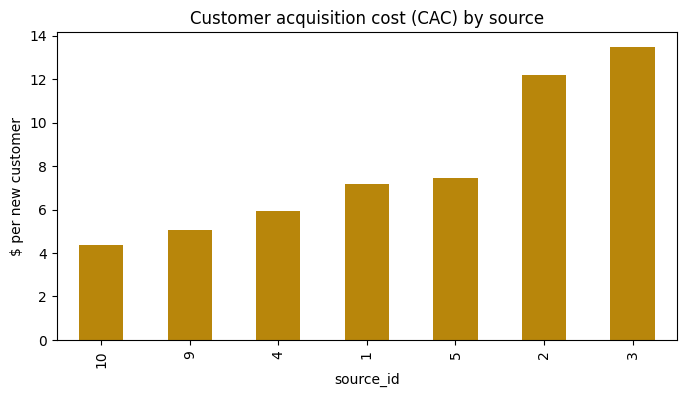

,0
source_id,
10,4.38
9,5.07
4,5.93
1,7.19
5,7.47
2,12.21
3,13.49


In [ ]:
fv_source = visits.sort_values('start_ts').groupby('uid').first()[['source_id']].reset_index()
customers = first_order.merge(fv_source, on='uid')
new_customers_by_source = customers.groupby('source_id')['uid'].nunique()
cost_by_source = costs.groupby('source_id')['costs'].sum()

cac = (cost_by_source / new_customers_by_source).dropna().sort_values()
plt.figure(figsize=(8, 4))
cac.plot(kind='bar', color='darkgoldenrod')
plt.title('Customer acquisition cost (CAC) by source')
plt.ylabel('$ per new customer')
plt.show()
cac.round(2)

CAC ranges from $4.38 for source 10 (the cheapest) up to $13.49 for source 3 (the most expensive). Source 3 is also one of the two biggest spenders overall, so it's an expensive channel and a large one.

### 4.3 Return on investment (ROI / ROMI)

Cheap CAC doesn't automatically mean a good deal, a source is only worthwhile if the LTV of the customers it brings is bigger than what it cost to get them. I calculate ROMI per source as (revenue from that source's customers − cost of that source) ÷ cost, using all-time revenue.

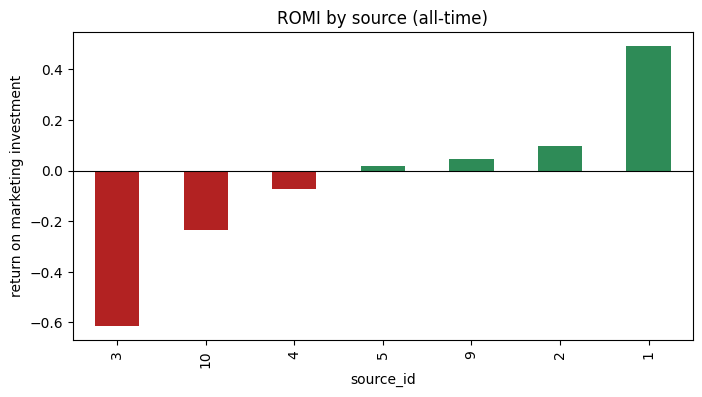

,0
source_id,
3,-61.4%
10,-23.6%
4,-7.2%
5,1.7%
9,4.4%
2,9.6%
1,49.2%


In [ ]:
revenue_by_source = orders.merge(fv_source, on='uid').groupby('source_id')['revenue'].sum()
ltv_by_source = revenue_by_source / new_customers_by_source
romi_by_source = ((revenue_by_source - cost_by_source) / cost_by_source).dropna().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['firebrick' if v < 0 else 'seagreen' for v in romi_by_source]
romi_by_source.plot(kind='bar', color=colors, ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ROMI by source (all-time)')
ax.set_ylabel('return on marketing investment')
plt.show()
romi_by_source.map(lambda x: f"{x:.1%}")

Only sources 1, 2, 5 and 9 show a positive return, and source 1 is the clear winner. Sources 3, 4 and 10 are losing money, and this includes source 10, which had the cheapest CAC. A low acquisition cost doesn't mean a good investment if the customers it brings don't spend much. Source 3 is the worst on both counts - expensive to acquire and unprofitable, which makes it the clearest candidate to cut.

All-time ROMI treats every cohort as if it had the same amount of time to mature, but a customer acquired in June 2017 has had 11 months to spend money, while one acquired in April 2018 had barely one. So instead of a single ROMI number, I want to see how ROMI (blended across all sources) evolves month by month for each acquisition cohort, this shows whether the investment is actually on track to pay off given enough time, or if it's structurally broken.

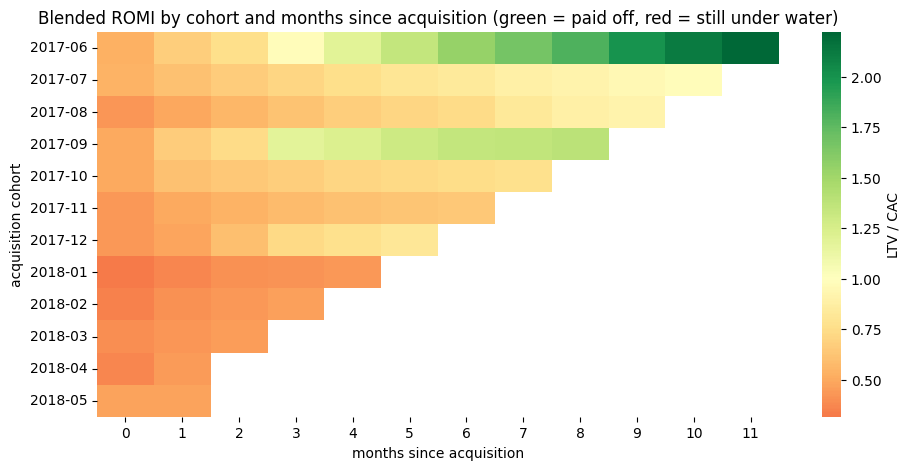

Average blended ROMI by maturity age (0 = acquisition month):
age
0     0.44
1     0.51
2     0.58
3     0.71
4     0.80
5     0.91
6     0.98
7     1.10
8     1.25
9     1.28
10    1.55
11    2.22


In [ ]:
cac_by_cohort_month = costs.groupby('month')['costs'].sum() / cohort_n
romi_curve = ltv_per_user.divide(cac_by_cohort_month, axis=0)

plt.figure(figsize=(11, 5))
sns.heatmap(romi_curve, annot=False, cmap='RdYlGn', center=1.0, cbar_kws={'label': 'LTV / CAC'})
plt.title('Blended ROMI by cohort and months since acquisition (green = paid off, red = still under water)')
plt.xlabel('months since acquisition')
plt.ylabel('acquisition cohort')
plt.show()

print("Average blended ROMI by maturity age (0 = acquisition month):")
print(romi_curve.mean().round(2).to_string())

**Result:** this is the most important chart in the notebook. Only the **very first cohort (June 2017)** - the one with the most time to mature -gets close to and eventually crosses break-even (LTV/CAC = 1.0), and only after about 6–7 months. Every cohort acquired later shows a *weaker* curve than the one before it: the January–May 2018 cohorts are stuck around 0.35–0.50 even at their current age, clearly on a worse trajectory than June 2017 was at the same age. So the blended marketing spend, overall, was not yet profitable within the year of data available, and the trend across cohorts is getting worse, not better. Combined with the total blended figures — **\$329,131.62 spent vs \$252,057.20 in revenue** (a spend-to-revenue ratio of 0.77) - the honest read is that Yandex.Afisha was, overall, spending more on marketing than it earned back during this period.

## Step 3. Conclusion - what should marketing do with the budget?

**Invest more:** Source 1 is the clear winnerç best ROMI (+49%) and below-average CAC ($7.19). Source 5 and 9 are near break-even, so I'd keep them steady and just watch. Source 2 brings the most valuable customers (highest LTV), but it's expensive ($12.21 CAC), so profit is small (+10%) - worth testing if that cost can drop.

**Cut or lower:** Source 3 is the biggest issue - big budget, highest CAC ($13.49), worst ROMI (-61%). I'd pause or shrink it. Source 4 also loses a little (-7%) and takes a big share of spend, so it deserves less too. Source 10 is the cheapest to buy ($4.38 CAC) but still loses money (-24%) - proof that cheap traffic isn't the same as good traffic.

**Why this approach:** CAC alone is misleading - it only shows cost, not return. Source 10 proves that. I trusted ROMI more, and used the median instead of the mean, since a few huge orders and sessions were skewing the "average" (top 1% of orders make up over a fifth of all revenue).

**Big picture:** the company spent ~$329K and earned back ~$252K — marketing hasn't paid for itself yet, and newer cohorts are doing worse, not better. Retention drops to ~6.5% after month one, and 72% of buyers decide the same day they arrive - so people buy fast or not at all, and "convincing" them later probably won't work.

**My suggestion:** shift budget toward source 1, cut source 3, reduce source 4, and focus ads on desktop and weekdays, since that's where most traffic and revenue already come from.